<a href="https://colab.research.google.com/github/leotamasauskas/LSTM-Long-Short-Term-Memory-for-time-series-forecasting-of-air-temperature-in-the-city-of-Bel-m-PA-./blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 11.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from google.colab import drive
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import optuna

In [ ]:
drive.mount('/content/drive')

# Caminho do arquivo no Google Drive
caminho_arquivo = '/content/drive/My Drive/Belem/BELEM_temperature_2m_1994-2024.csv'

# Ler o arquivo
dados = pd.read_csv(caminho_arquivo)  # Usar '\t' para separador de tabulação

# Exibir as primeiras linhas
print(dados.head())

Mounted at /content/drive
         date  temperature_2m
0  1994-01-01      298.841116
1  1994-01-02      298.865554
2  1994-01-03      298.180084
3  1994-01-04      297.645098
4  1994-01-05      298.587193


In [ ]:
# Certificar-se de que a coluna 'date' é datetime
dados['date'] = pd.to_datetime(dados['date'])

# Definir a coluna 'date' como índice
dados = dados.set_index('date')

# Verificar valores faltantes em 'temperature_2m'
print("Valores faltantes em temperature_2m:", dados['temperature_2m'].isnull().sum())

# Remover linhas com valores faltantes em 'temperature_2m'
dados = dados.dropna(subset=['temperature_2m'])

# Converter temperatura de Kelvin para Celsius
dados['temperature_2m'] = dados['temperature_2m'] - 273.15

# Extrair os componentes de data
dados['ano'] = dados.index.year
dados['mes'] = dados.index.month
dados['dia'] = dados.index.day

# Criar uma coluna 'data' (caso queira manter a data como uma coluna separada)
dados['data'] = dados.index

# Opcional: redefinir o índice para ter uma coluna de data separada
dados = dados.reset_index().rename(columns={'date': 'data'})

# Exibir estatísticas descritivas
print(dados['temperature_2m'].describe())

# Exibir as primeiras linhas para conferência
print(dados.head())

Valores faltantes em temperature_2m: 0
count    11323.000000
mean        26.589949
std          1.071000
min         23.536224
25%         25.765164
50%         26.580064
75%         27.448345
max         29.529403
Name: temperature_2m, dtype: float64
        data  temperature_2m   ano  mes  dia       data
0 1994-01-01       25.691116  1994    1    1 1994-01-01
1 1994-01-02       25.715554  1994    1    2 1994-01-02
2 1994-01-03       25.030084  1994    1    3 1994-01-03
3 1994-01-04       24.495098  1994    1    4 1994-01-04
4 1994-01-05       25.437193  1994    1    5 1994-01-05


In [ ]:
def create_dataset(data, look_back=7):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

# Selecionar a coluna 'temperature_2m' para a série temporal
series = dados['temperature_2m'].values.reshape(-1, 1)


# Aplicar o janelamento de 7 dias
X, y = create_dataset(series, look_back=7)

In [ ]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)


In [ ]:
# Dividir o conjunto de treinamento em treino e validação
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, shuffle=False)

In [ ]:
# Normalizar apenas os dados de entrada (X) após a divisão
scaler = MinMaxScaler(feature_range=(0, 1))
X_train = scaler.fit_transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_val = scaler.transform(X_val.reshape(-1, 1)).reshape(X_val.shape)
X_test = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)

In [ ]:
# Verificar o tamanho dos conjuntos de treino, validação e teste
print("Tamanho de X_train:", len(X_train))
print("Tamanho de X_val:", len(X_val))
print("Tamanho de X_test:", len(X_test))

print("Tamanho de y_train:", len(y_train))
print("Tamanho de y_val:", len(y_val))
print("Tamanho de y_test:", len(y_test))

Tamanho de X_train: 8175
Tamanho de X_val: 1443
Tamanho de X_test: 1698
Tamanho de y_train: 8175
Tamanho de y_val: 1443
Tamanho de y_test: 1698


In [ ]:
# Reshape dos dados para o formato [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))  # Formato (amostras, 7, 1)
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))          # Formato (amostras, 7, 1)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))      # Formato (amostras, 7, 1)

In [ ]:
# Função para criar o modelo LSTM
def create_model(trial):
    model = Sequential()
    n_layers = trial.suggest_int('n_layers', 1, 3)
    for i in range(n_layers):
        num_hidden = trial.suggest_int(f'n_units_l{i}', 32, 128)
        model.add(LSTM(num_hidden, return_sequences=(i < n_layers - 1), input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model


In [ ]:
# Função objetivo para o Optuna
def objective(trial):
    model = create_model(trial)
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=0)

    # Avaliação do modelo
    evaluation_results = model.evaluate(X_test, y_test, verbose=0)

    # Retornar o valor da perda (loss) diretamente
    return evaluation_results

In [ ]:
# Otimização com Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

[I 2025-03-31 14:15:12,783] A new study created in memory with name: no-name-75b57920-fd4b-4d4a-ab23-93bde826ef9a
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[I 2025-03-31 14:16:09,466] Trial 0 finished with value: 0.3137396574020386 and parameters: {'n_layers': 1, 'n_units_l0': 107}. Best is trial 0 with value: 0.3137396574020386.
[I 2025-03-31 14:18:15,399] Trial 1 finished with value: 0.23010149598121643 and parameters: {'n_layers': 3, 'n_units_l0': 115, 'n_units_l1': 57, 'n_units_l2': 95}. Best is trial 1 with value: 0.23010149598121643.
[I 2025-03-31 14:19:53,841] Trial 2 finished with value: 0.2520686089992523 and parameters: {'n_layers': 2, 'n_units_l0': 54, 'n_units_l1': 113}. Best is trial 1 with value: 0.23010149598121643.
[I 2025-03-31 1

In [ ]:
# Melhores parâmetros encontrados
best_params = study.best_params
print("Melhores parâmetros:", best_params)

Melhores parâmetros: {'n_layers': 2, 'n_units_l0': 62, 'n_units_l1': 117}


In [ ]:
# Construção do modelo com os melhores parâmetros
model = Sequential()
n_layers = best_params['n_layers']
for i in range(n_layers):
    num_hidden = best_params[f'n_units_l{i}']
    model.add(LSTM(num_hidden, return_sequences=(i < n_layers - 1), input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

In [ ]:
# Treinamento do modelo com conjunto de validação
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val), verbose=2)

Epoch 1/30
256/256 - 9s - 34ms/step - loss: 75.1977 - val_loss: 1.1225
Epoch 2/30
256/256 - 8s - 31ms/step - loss: 1.0760 - val_loss: 1.1246
Epoch 3/30
256/256 - 6s - 24ms/step - loss: 1.0724 - val_loss: 1.1133
Epoch 4/30
256/256 - 4s - 16ms/step - loss: 1.0647 - val_loss: 1.1161
Epoch 5/30
256/256 - 6s - 24ms/step - loss: 1.0102 - val_loss: 1.0192
Epoch 6/30
256/256 - 4s - 16ms/step - loss: 0.7191 - val_loss: 0.4918
Epoch 7/30
256/256 - 5s - 20ms/step - loss: 0.3395 - val_loss: 0.3162
Epoch 8/30
256/256 - 5s - 18ms/step - loss: 0.3050 - val_loss: 0.3132
Epoch 9/30
256/256 - 4s - 14ms/step - loss: 0.2892 - val_loss: 0.2824
Epoch 10/30
256/256 - 3s - 13ms/step - loss: 0.2772 - val_loss: 0.2733
Epoch 11/30
256/256 - 6s - 25ms/step - loss: 0.2641 - val_loss: 0.2907
Epoch 12/30
256/256 - 4s - 15ms/step - loss: 0.2524 - val_loss: 0.2464
Epoch 13/30
256/256 - 3s - 13ms/step - loss: 0.2454 - val_loss: 0.2408
Epoch 14/30
256/256 - 6s - 25ms/step - loss: 0.2338 - val_loss: 0.2299
Epoch 15/30
25

In [ ]:
# Avaliação do modelo
loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Loss no conjunto de teste: {loss}')

Loss no conjunto de teste: 0.2150518000125885


In [ ]:
# Fazer previsões
y_pred = model.predict(X_test)

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [ ]:
# Exibir as previsões
print("Previsões:", y_pred.flatten())
print("Valores reais:", y_test.flatten())


Previsões: [26.945358 26.876205 26.979069 ... 27.273504 25.925425 26.610996]
Valores reais: [26.9448925  27.03789864 26.21991564 ... 25.68102417 26.25386645
 27.19699504]


In [ ]:
test_index = dados.index[-len(y_test):]

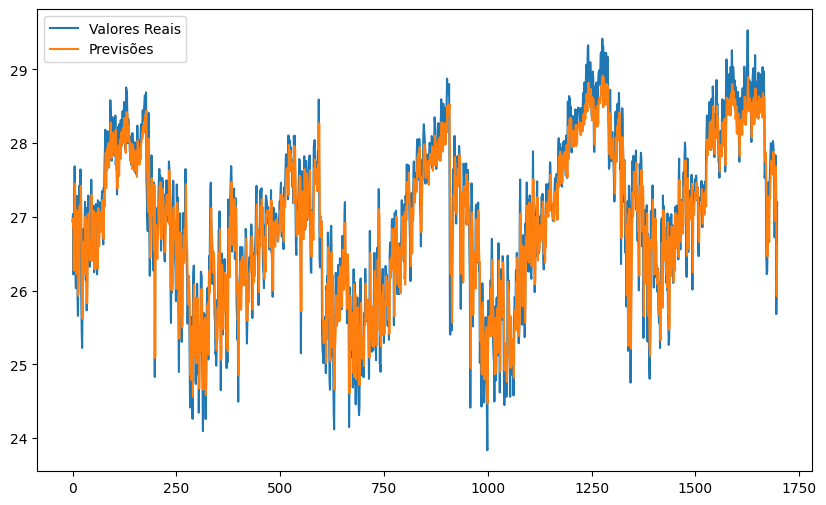

In [ ]:
# Plotar os valores reais e as previsões
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Valores Reais')
plt.plot(y_pred, label='Previsões')
plt.legend()
plt.show()

In [ ]:
# Calcular métricas na escala original
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Exibir métricas na escala original
print(f"MAE (Escala Original): {mae:.2f}")
print(f"MSE (Escala Original): {mse:.2f}")
print(f"RMSE (Escala Original): {rmse:.2f}")
print(f"R² (Escala Original): {r2:.2f}")

MAE (Escala Original): 0.36
MSE (Escala Original): 0.22
RMSE (Escala Original): 0.46
R² (Escala Original): 0.82


In [ ]:



# Criar o DataFrame de comparação
comparison_df = pd.DataFrame({
    'Valor Real': y_test.flatten(),  # Valores reais
    'Previsão': y_pred.flatten()  # Previsões do modelo
}, index=test_index)  # Definir o índice como test_index

# Exibir as primeiras linhas do DataFrame
print(comparison_df.head())

      Valor Real   Previsão
9625   26.944893  26.945358
9626   27.037899  26.876205
9627   26.219916  26.979069
9628   26.837536  26.272869
9629   27.071900  26.923920


In [ ]:
comparison_df.index = pd.to_datetime(comparison_df.index)
comparison_df.index = dados.index[-len(comparison_df):]  # Atribui as datas corretas

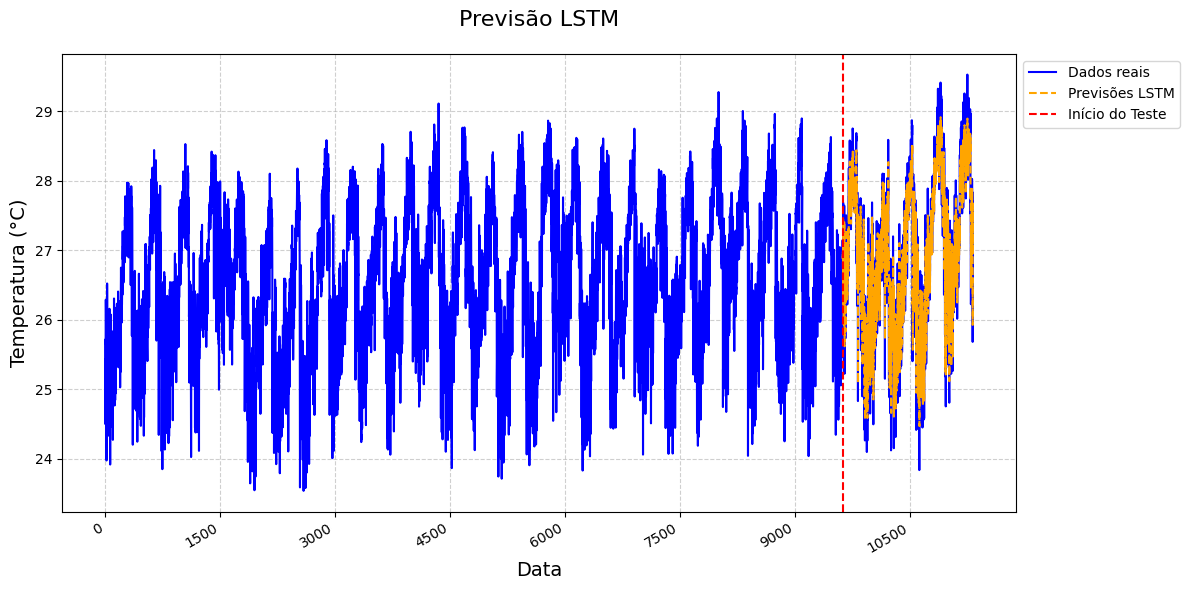

In [ ]:

# Criando a figura
plt.figure(figsize=(12, 6))

# Plotando os dados reais
plt.plot(dados['temperature_2m'], label='Dados reais', color='blue')

# Plotando as previsões LSTM (apenas a coluna 'Previsão')
plt.plot(comparison_df.index, comparison_df['Previsão'], label='Previsões LSTM', linestyle='dashed', color='orange')

# Adicionando uma linha vertical no início do teste
plt.axvline(x=comparison_df.index[0], color='red', linestyle='--', label='Início do Teste')

# Adicionando legenda, título e exibindo o gráfico
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Legenda fora do gráfico
plt.title('Previsão LSTM', fontsize=16, pad=20)
plt.xlabel('Data', fontsize=14)
plt.ylabel('Temperatura (°C)', fontsize=14)

# Ajustar o formato das datas no eixo x
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))  # Exibir menos datas no eixo x
plt.gcf().autofmt_xdate()  # Rotacionar as datas para melhor visualização

# Adicionar uma grade ao gráfico
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar o layout
plt.tight_layout()

# Mostrar o gráfico
plt.show()

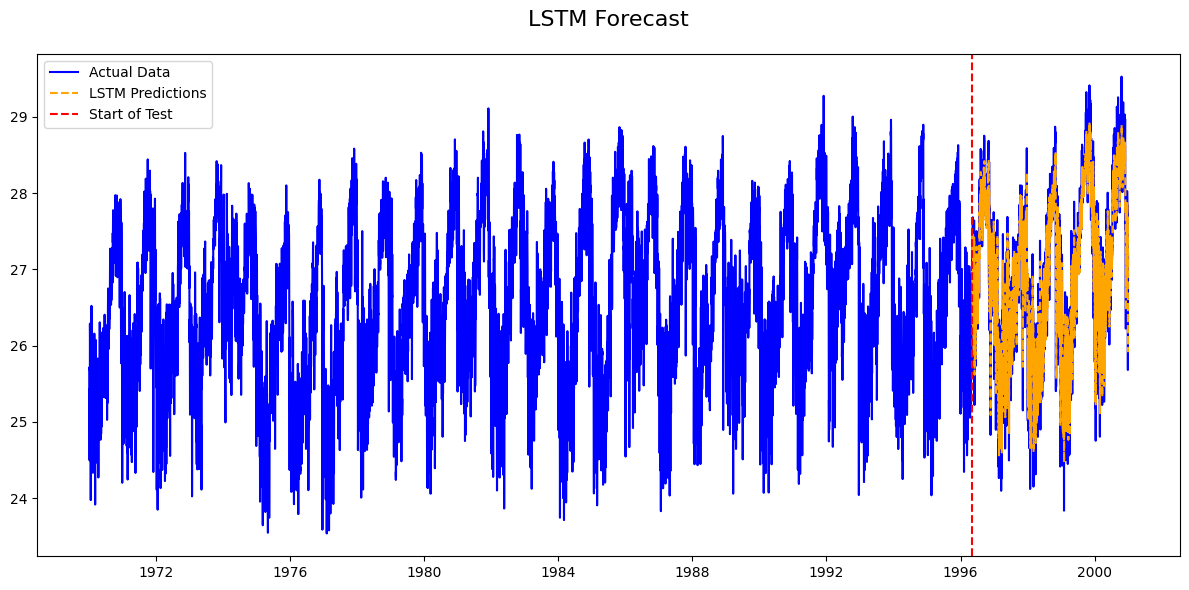

In [ ]:
import matplotlib.dates as mdates

# Creating the figure
plt.figure(figsize=(12, 6))

# Plotting the actual data
plt.plot(dados['temperature_2m'], label='Actual Data', color='blue')

# Plotting the LSTM predictions (only the 'Prediction' column)
plt.plot(comparison_df.index, comparison_df['Previsão'], label='LSTM Predictions', linestyle='dashed', color='orange')

# Adding a vertical line at the start of the test
plt.axvline(x=comparison_df.index[0], color='red', linestyle='--', label='Start of Test')

# Adding legend, title, and displaying the plot
plt.legend()  # Legend outside the plot
plt.title('LSTM Forecast', fontsize=16, pad=20)
#plt.xlabel('Date', fontsize=14)
#plt.ylabel('Temperature (°C)', fontsize=14)

# Adjusting the date format on the x-axis
plt.gca().xaxis.set_major_locator(mdates.YearLocator(4))  # Display every 4 years
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Show only the year

# Adjust layout for better visualization
plt.tight_layout()

# Show the plot
plt.show()
